<a href="https://colab.research.google.com/github/AkankshaB123/ML/blob/main/Random_Forest_Healthcare_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# =============================================================================
# Random Forest
# =============================================================================

# =============================================================================
# Case --
#Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.
#They describe characteristics of the cell nuclei present in the image.
# =============================================================================


# =============================================================================
# Setting the Environment
# =============================================================================
import os
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from urllib.request import urlopen

plt.style.use('ggplot')
pd.set_option('display.max_columns', 500)

In [16]:
# =============================================================================
# # Importing the dataset
# =============================================================================
breast_cancer = pd.read_csv('/content/sample_data/data.csv')
names = ['id', 'diagnosis', 'radius_mean',
         'texture_mean', 'perimeter_mean', 'area_mean',
         'smoothness_mean', 'compactness_mean',
         'concavity_mean','concave_points_mean',
         'symmetry_mean', 'fractal_dimension_mean',
         'radius_se', 'texture_se', 'perimeter_se',
         'area_se', 'smoothness_se', 'compactness_se',
         'concavity_se', 'concave_points_se',
         'symmetry_se', 'fractal_dimension_se',
         'radius_worst', 'texture_worst',
         'perimeter_worst', 'area_worst',
         'smoothness_worst', 'compactness_worst',
         'concavity_worst', 'concave_points_worst',
         'symmetry_worst', 'fractal_dimension_worst']

dx = ['Benign', 'Malignant']

In [17]:
# =============================================================================
# # Data Cleaning
# =============================================================================


# =============================================================================
# minor cleanage like setting the `id_number` to be the data frame index, along
# with converting the `diagnosis` to the standard binary 1, 0 representation using the `map()` function.
# =============================================================================

# Setting 'id_number' as our index
breast_cancer.set_index(['id'], inplace = True)

# Converted to binary to help later on with models and plots
breast_cancer['diagnosis'] = breast_cancer['diagnosis'].map({'M':1, 'B':0})

In [18]:
# =============================================================================
# Missing Values
# =============================================================================

breast_cancer.isnull().sum()

# For later use
names_index = names[2:]



# =============================================================================
# Exploratory Data Analysis
# =============================================================================

breast_cancer.head()

breast_cancer.describe()

print("Here's the dimensions of our data frame:\n",
     breast_cancer.shape)
print("Here's the data types of our columns:\n",
     breast_cancer.dtypes)

Here's the dimensions of our data frame:
 (569, 31)
Here's the data types of our columns:
 diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64

In [19]:
# =============================================================================
# Split the data into training and test sets
# =============================================================================

feature_space = breast_cancer.iloc[:, breast_cancer.columns != 'diagnosis']
feature_class = breast_cancer.iloc[:, breast_cancer.columns == 'diagnosis']


training_set, test_set, class_set, test_class_set = train_test_split(feature_space,
                                                                    feature_class,
                                                                    test_size = 0.20,
                                                                    random_state = 42)

# Cleaning test sets to avoid future warning messages
class_set = class_set.values.ravel()
test_class_set = test_class_set.values.ravel()

In [20]:
# =============================================================================
# Fitting the Random Forest Model
# =============================================================================


# Now, let's create the model, starting with parameter tuning. Here are the parameters we will be tuning in this tutorial:

# **max_depth**: The maximum splits for all trees in the forest.
#bootstrap: An indicator of whether or not we want to use bootstrap samples when building trees.
# **max_features**: The maximum number of features that will be used in node splitting — the main difference I previously mentioned between bagging trees and random forest. Typically, you want a value that is less than p, where p is all features in your data set.
# **criterion**: This is the metric used to asses the stopping criteria for the decision trees.


# Set the random state for reproducibility
fit_rf = RandomForestClassifier(random_state=42)

In [21]:
# =============================================================================
#  Hyperparameters Optimization
# =============================================================================

# =============================================================================
# Utilizing the `GridSearchCV` functionality, let's create a dictionary with parameters we are looking to optimize to create the best model for our data. Setting the `n_jobs` to 3 tells the grid search to run three jobs in parallel, reducing the time the function will take to compute the best parameters. Have included the timer to see how long different jobs took;
#that led me to ultimately decide to use three parallel jobs.
#This will help set the parameters we will use to tune one final parameter: the number of trees in our forest.
# =============================================================================

np.random.seed(42)
start = time.time()

param_dist = {'max_depth': [2, 3, 4],
              'bootstrap': [True, False],
              'max_features': ['auto', 'sqrt', 'log2', None],
              'criterion': ['gini', 'entropy']}

cv_rf = GridSearchCV(fit_rf, cv = 10,
                     param_grid=param_dist,
                     n_jobs = 3)

cv_rf.fit(training_set, class_set)
print('Best Parameters using grid search: \n',
      cv_rf.best_params_)
end = time.time()
print('Time taken in grid search: {0: .2f}'.format(end - start))

# Set best parameters given by grid search
fit_rf.set_params(criterion = 'gini',
                  max_features = 'log2',
                  max_depth = 3)


#Notice how we didn't utilize the `bootstrap: True` parameter, this will make sense in the following section.

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
49 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils

Best Parameters using grid search: 
 {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 4, 'max_features': 'log2'}
Time taken in grid search:  115.23


RandomForestClassifier(max_depth=3, max_features='log2', random_state=42)

OOB Error rate for 400 trees is: 0.04835


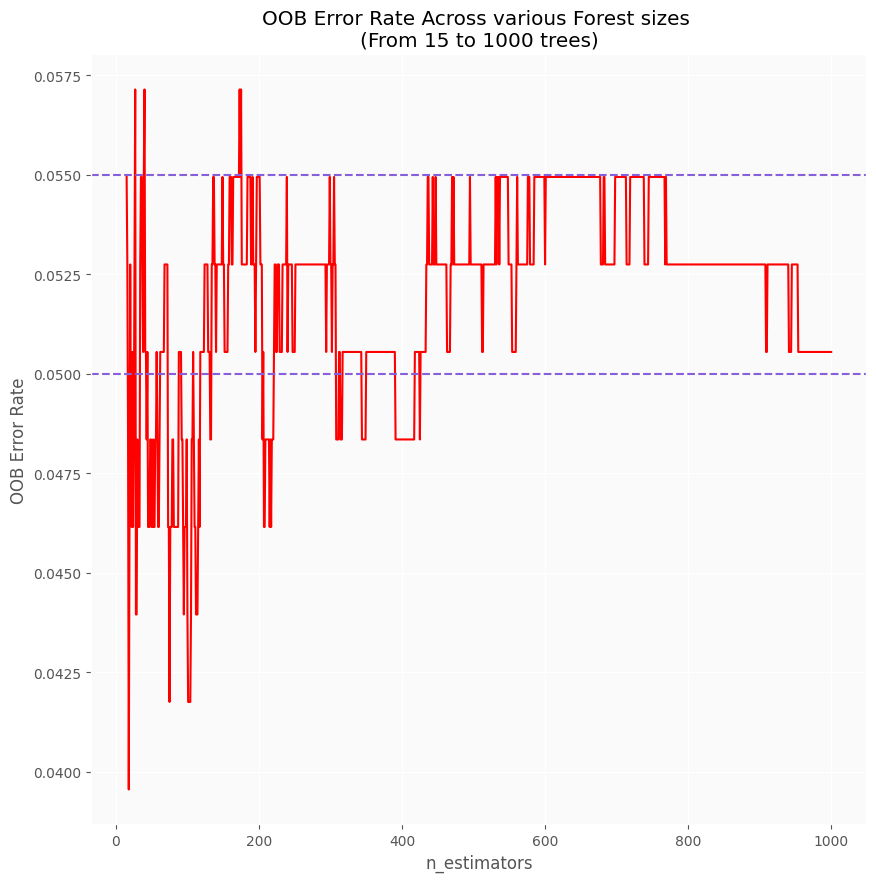

In [22]:
# =============================================================================
# Out of Error Bag Rate
# =============================================================================


# =============================================================================
# Another useful feature of random forest is the concept of an out-of-bag (OOB) error rate. Because only two-thirds of the data are used to train each tree when building the forest, one-third of unseen data can be used in a way that is advantageous to our accuracy metrics without being as computationally expensive as something like cross validation, for instance.
#As outlined below, when calculating OOB, two parameters have to be changed. Also, by utilizing a `for-loop` across a multitude of forest sizes, we can calculate the OOB error rate and use it to asses how many trees are appropriate for our model!
#**NOTE**: When calculating the oob score, setting `bootstrap=True` will produce errors,
# =============================================================================


fit_rf.set_params(warm_start=True,
                  oob_score=True)

min_estimators = 15
max_estimators = 1000

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf.set_params(n_estimators=i)
    fit_rf.fit(training_set, class_set)

    oob_error = 1 - fit_rf.oob_score_
    error_rate[i] = oob_error


# Convert dictionary to a pandas series for easy plotting
oob_series = pd.Series(error_rate)


fig, ax = plt.subplots(figsize=(10, 10))

ax.set_facecolor('#fafafa')

oob_series.plot(kind='line',
                color = 'red')
plt.axhline(0.055,
            color='#875FDB',
           linestyle='--')
plt.axhline(0.05,
            color='#875FDB',
           linestyle='--')
plt.xlabel('n_estimators')
plt.ylabel('OOB Error Rate')
plt.title('OOB Error Rate Across various Forest sizes \n(From 15 to 1000 trees)')


#The OOB error rate starts to oscilate at around 400 trees, so I will go ahead and use my judgement to use 400 trees in my forest. Using the `pandas` series object I can easily find the OOB error rate for the estimator as follows:


print('OOB Error rate for 400 trees is: {0:.5f}'.format(oob_series[400]))

In [23]:
# =============================================================================
# Traditional Training and Test Set Split
# =============================================================================


fit_rf.set_params(n_estimators=400,
                  bootstrap = True,
                  warm_start=False,
                  oob_score=False)


fit_rf.fit(training_set, class_set)

RandomForestClassifier(max_depth=3, max_features='log2', n_estimators=400,
                       random_state=42)

In [24]:
# =============================================================================
# Variable Importance
# =============================================================================


def variable_importance(fit):
    """
    Purpose
    ----------
    Checks if model is fitted CART model then produces variable importance
    and respective indices in dictionary.

    Parameters
    ----------
    * fit:  Fitted model containing the attribute feature_importances_

    Returns
    ----------
    Dictionary containing arrays with importance score and index of columns
    ordered in descending order of importance.
    """
    try:
        if not hasattr(fit, 'fit'):
            return print("'{0}' is not an instantiated model from scikit-learn".format(fit))

        # Captures whether the model has been trained
        if not vars(fit)["estimators_"]:
            return print("Model does not appear to be trained.")
    except KeyError:
        print("Model entered does not contain 'estimators_' attribute.")

    importances = fit.feature_importances_
    indices = np.argsort(importances)[::-1]
    return {'importance': importances,
            'index': indices}


var_imp_rf = variable_importance(fit_rf)

importances_rf = var_imp_rf['importance']

indices_rf = var_imp_rf['index']




def print_var_importance(importance, indices, name_index):
    """
    Purpose
    ----------
    Prints dependent variable names ordered from largest to smallest
    based on information gain for CART model.
    Parameters
    ----------
    * importance: Array returned from feature_importances_ for CART
                models organized by dataframe index
    * indices: Organized index of dataframe from largest to smallest
                based on feature_importances_
    * name_index: Name of columns included in model

    Returns
    ----------
    Prints feature importance in descending order
    """
    print("Feature ranking:")

    for f in range(0, indices.shape[0]):
        i = f
        print("{0}. The feature '{1}' has a Mean Decrease in Impurity of {2:.5f}"
              .format(f + 1,
                      names_index[indices[i]],
                      importance[indices[f]]))



print_var_importance(importances_rf, indices_rf, names_index)

Feature ranking:
1. The feature 'area_worst' has a Mean Decrease in Impurity of 0.12986
2. The feature 'perimeter_worst' has a Mean Decrease in Impurity of 0.12095
3. The feature 'concave_points_worst' has a Mean Decrease in Impurity of 0.11555
4. The feature 'concave_points_mean' has a Mean Decrease in Impurity of 0.10014
5. The feature 'radius_worst' has a Mean Decrease in Impurity of 0.07805
6. The feature 'concavity_mean' has a Mean Decrease in Impurity of 0.06214
7. The feature 'area_mean' has a Mean Decrease in Impurity of 0.05656
8. The feature 'radius_mean' has a Mean Decrease in Impurity of 0.05457
9. The feature 'perimeter_mean' has a Mean Decrease in Impurity of 0.05174
10. The feature 'area_se' has a Mean Decrease in Impurity of 0.04326
11. The feature 'concavity_worst' has a Mean Decrease in Impurity of 0.03866
12. The feature 'compactness_worst' has a Mean Decrease in Impurity of 0.02033
13. The feature 'compactness_mean' has a Mean Decrease in Impurity of 0.01616
14. The

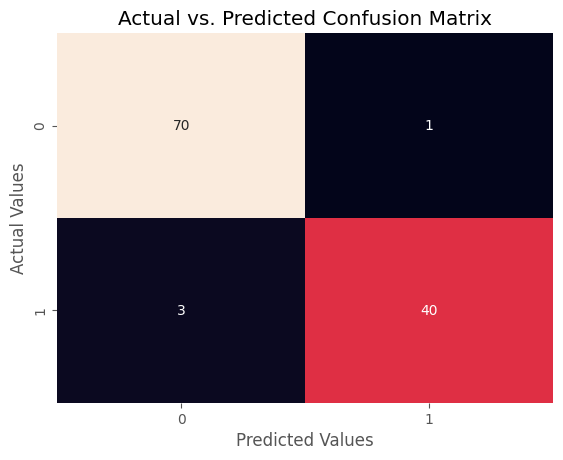

Here is our mean accuracy on the test set:
 0.965
The test error rate for our model is:
  0.0351


In [25]:
# =============================================================================
# Test Set Metrics
# =============================================================================

predictions_rf = fit_rf.predict(test_set)

def create_conf_mat(test_class_set, predictions):
    """Function returns confusion matrix comparing two arrays"""
    if (len(test_class_set.shape) != len(predictions.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (test_class_set.shape != predictions.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = test_class_set,
                                        columns = predictions)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb


conf_mat = create_conf_mat(test_class_set, predictions_rf)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()



accuracy_rf = fit_rf.score(test_set, test_class_set)

print("Here is our mean accuracy on the test set:\n {0:.3f}"\
      .format(accuracy_rf))



# Here we calculate the test error rate!
test_error_rate_rf = 1 - accuracy_rf
print("The test error rate for our model is:\n {0: .4f}"\
      .format(test_error_rate_rf))

In [26]:
# =============================================================================
# ROC Curve
# =============================================================================

# We grab the second array from the output which corresponds to
# to the predicted probabilites of positive classes
# Ordered wrt fit.classes_ in our case [0, 1] where 1 is our positive class
predictions_prob = fit_rf.predict_proba(test_set)[:, 1]

fpr2, tpr2, _ = roc_curve(test_class_set,
                          predictions_prob,
                          pos_label = 1)

auc_rf = auc(fpr2, tpr2)

In [27]:
# =============================================================================
# The classification report is available through `sklearn.metrics`, this report gives many important classification metrics including:
#+ `Precision`: also the positive predictive value, is the number of correct predictions divided by the number of correct predictions plus false positives, so $tp / (tp + fp)$
#+ `Recall`: also known as the sensitivity, is the number of correct predictions divided by the total number of instances so $tp / (tp + fn)$ where $fn$ is the number of false negatives
#+ `f1-score`: this is defined as the *weighted harmonic mean* of both the precision and recall, where the f1-score at 1 is the best value and worst value at 0, as defined by the [documentation](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support)
#+ `support`: number of instances that are the correct target values
# =============================================================================

def print_class_report(predictions, alg_name):
    """
    Purpose
    ----------
    Function helps automate the report generated by the
    sklearn package. Useful for multiple model comparison

    Parameters:
    ----------
    predictions: The predictions made by the algorithm used
    alg_name: String containing the name of the algorithm used

    Returns:
    ----------
    Returns classification report generated from sklearn.
    """
    print('Classification Report for {0}:'.format(alg_name))
    print(classification_report(predictions,
            test_class_set,
            target_names = dx))


class_report = print_class_report(predictions_rf, 'Random Forest')

Classification Report for Random Forest:
              precision    recall  f1-score   support

      Benign       0.99      0.96      0.97        73
   Malignant       0.93      0.98      0.95        41

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

